### De la Predicción de Puntos a la Conquista de la Victoria: Un Nuevo Enfoque

El presente reporte técnico documenta la evolución de nuestra arquitectura de análisis: pasamos de un modelo de regresión lineal (enfocado en predecir puntos totales) a un modelo de **Clasificación**. El propósito es determinar con rigor estadístico si la altitud de las sedes en la Liga MX funciona como un clasificador efectivo para predecir la capacidad de sumar puntos (empate o victoria) del visitante.

A diferencia del estudio anterior, este análisis simplifica la complejidad del fútbol para obtener una respuesta más útil y contundente: **¿Es la diferencia de altitud capaz de impedir que el visitante puntúe?** Evaluaremos el desempeño mediante validación cruzada y métricas de calidad para asegurar la robustez de los hallazgos.

#### 1. Antecedentes y Hallazgos del estudio previo

En el análisis inicial de regresión lineal, se confirmó que la altitud es un factor de desgaste físico real en la Liga MX. Los resultados fundamentales que sirven de base para este nuevo modelo de clasificación son:

* **Correlación Negativa y Significativa:** Se demostró que el rendimiento del visitante decrece a medida que aumenta el diferencial de altitud, con un p-value de 0.0440, lo que valida la altitud como una variable explicativa legítima.

* **La complejidad de la distribución de puntos:** El fútbol presenta una naturaleza discreta y volátil (0, 1 o 3 puntos). Predecir un puntaje exacto se ve dificultado por la frecuencia de los empates, los cuales actúan como un factor de equilibrio que "suaviza" el impacto de las variables físicas en modelos lineales.

* **Decisión estratégica: El enfoque en la resistencia:** Para obtener una respuesta más útil y contundente, este reporte transforma el problema en uno de Clasificación Binaria. En lugar de estimar un promedio de puntos, buscamos calcular la probabilidad de que el visitante logre Pontuar (rescatar un empate o victoria) frente al escenario de la derrota total.

Este enfoque permite evaluar si la altitud es capaz de quebrar la resistencia del visitante, convirtiéndose en el factor determinante para que el equipo regrese a casa con las manos vacías.

#### 2. Definición del Problema de Clasificación

##### 2.1 Justificación: Del "Impuesto de Puntos" a la Probabilidad de Éxito

Identificamos que cada 100 metros de ascenso actúan como un "impuesto" al rendimiento, restando en promedio 0.0062 puntos al visitante. Sin embargo, en la realidad competitiva, los puntos no se entregan en decimales. Por ello, transformamos el problema: en lugar de medir cuánto puntaje se "pierde" teóricamente en el camino, este modelo de Regresión Logística busca clasificar si ese "impuesto" es lo suficientemente severo como para quebrar la resistencia del visitante y forzar su derrota.

##### 2.2 Construcción de la Variable de Salida ($y$)

Para este análisis cualitativo, hemos construido la variable binaria **"Puntaje_V"**:

* **Clase 1 (Éxito):** El visitante logra sumar puntos (Empate o Victoria), superando el obstáculo geográfico.
* **Clase 0 (Fracaso):** El visitante pierde el encuentro (0 puntos), sucumbiendo ante la localía o el efecto acumulado de la altitud.

Esta binarización nos permite calcular la probabilidad logística de "no volver con las manos vacías". Es decir, **¿en qué punto del ascenso el "impuesto de puntos" se vuelve tan alto que la probabilidad de puntuar cae por debajo del umbral crítico?**

##### 2.3 Relevancia y Balance de Clases

La relevancia de este modelo radica en su capacidad para actuar donde la estadística tradicional es insuficiente. Al redefinir el éxito como "sumar puntos", logramos un conjunto de datos mucho más equilibrado y representativo de la competencia en la Liga MX.

El Desafío Técnico:

* **Optimización del Balance de Clases:** Al consolidar el empate y la victoria en una sola categoría de éxito, se proporciona al modelo una base de datos más equilibrada. Esto evita que el algoritmo desarrolle un sesgo hacia la clase mayoritaria y permite que aprenda a distinguir con mayor precisión las características que permiten al visitante sumar puntos.

* **Identificación del Punto de Quiebre:** El objetivo es determinar si la estructura de los datos permite identificar un "umbral de altitud" donde la probabilidad de rescatar puntos se reduce significativamente. Esto transforma el análisis en una herramienta diagnóstica para identificar partidos de alto riesgo basados en la exigencia geográfica.

#### 3. Metodología

Para evaluar el desempeño del modelo de forma objetiva y asegurar su capacidad de generalización ante nuevos datos, dividimos nuestro conjunto de datos en dos subconjuntos independientes: **Entrenamiento (80%)** y **Prueba (20%)**.

##### 3.1 Importancia de la Estratificación

Incluso al mejorar el equilibrio de clases mediante el enfoque de **"Pontuar"**, el fútbol sigue siendo un fenómeno con una distribución de resultados muy específica. Una división aleatoria simple corre el riesgo de concentrar accidentalmente la mayoría de las derrotas o los éxitos en uno de los grupos, lo que invalidaría cualquier conclusión.

Para neutralizar este riesgo, aplicamos una división estratificada. Esta técnica fuerza al algoritmo a mantener la proporción exacta entre "Capacidad de Pontuar" (Clase 1) y "Derrota" (Clase 0) en ambos subconjuntos. Esto es fundamental por dos razones:

* **Representatividad Proporcional:** Garantiza que tanto la fase de aprendizaje como la de evaluación se realicen bajo la misma realidad estadística de la Liga MX, capturando fielmente la dificultad de sumar puntos de visita.

* **Estabilidad de las Métricas:** Al asegurar que el conjunto de prueba sea un "espejo" del de entrenamiento, evitamos que las métricas de calidad (como la precisión o la sensibilidad) se vean infladas o castigadas por una mala distribución de los datos, otorgando validez científica al modelo final.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Preparación del Dataset
df = pd.read_csv('matches_LigaMX20212025.csv', sep=';', encoding='latin1')

altitudes = {
    'Querétaro': 1820, 'Pachuca': 2400, 'Necaxa': 1880, 'FC Juárez': 1137,
    'UNAM': 2240, 'Guadalajara': 1566, 'Monterrey': 540, 'Santos Laguna': 1120,
    'Cruz Azul': 2240, 'América': 2240, 'Toluca': 2660, 'León': 1815,
    'Atlético San Luis': 1860, 'Tijuana': 20, 'Mazatlán': 5, 'Atlas': 1566,
    'Puebla': 2135, 'UANL': 540
}

df['Alt_Home'] = df['Home'].str.strip().map(altitudes)
df['Alt_Away'] = df['Away'].str.strip().map(altitudes)
df['Dif_Altitud'] = df['Alt_Home'] - df['Alt_Away']

# 2. Binarización: Enfoque en Pontuar (Victoria o Empate = 1, Derrota = 0)
def binarizar_pontuar(score):
    try:
        s = str(score).replace('\x96', '-').replace('–', '-').replace('—', '-')
        goles = s.split('-')
        # El visitante suma si sus goles son iguales o mayores a los del local
        return 1 if int(goles[1]) >= int(goles[0]) else 0
    except: return None

df['Pontua_V'] = df['Score'].apply(binarizar_pontuar)
df_modelo = df.dropna(subset=['Pontua_V', 'Dif_Altitud']).copy()

# 3. División Estratificada 80/20
X = df_modelo[['Dif_Altitud']]
y = df_modelo['Pontua_V']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 4. Generación de tabla de evidencia de estratificación
def obtener_proporciones(data, nombre):
    return {
        "Conjunto": nombre,
        "Tamaño (N)": len(data),
        "Puntúa (Clase 1)": f"{(data.mean()*100):.2f}%",
        "Derrota (Clase 0)": f"{(1-data.mean())*100:.2f}%"
    }

evidencia = pd.DataFrame([
    obtener_proporciones(y, "Original (Completo)"),
    obtener_proporciones(y_train, "Entrenamiento (80%)"),
    obtener_proporciones(y_test, "Prueba (20%)")
])

print("Evidencia de consistencia mediante división estratificada:")
display(evidencia)

Evidencia de consistencia mediante división estratificada:


,Conjunto,Tamaño (N),Puntúa (Clase 1),Derrota (Clase 0)
0,Original (Completo),1522,54.86%,45.14%
1,Entrenamiento (80%),1217,54.89%,45.11%
2,Prueba (20%),305,54.75%,45.25%


##### 3.2 Análisis de la Distribución de Datos

Los resultados obtenidos tras la división estratificada no solo validan la consistencia del proceso, sino que revelan una estructura de datos ideal para el modelado:

* **Consistencia estadistica:** La variación en la proporción de éxito (Capacidad de Pontuar) entre el conjunto original (54.86%), el de entrenamiento (54.89%) y el de prueba (54.75%) es despreciable. Esto asegura que los hallazgos del modelo no sean producto de un sesgo en la selección de las muestras.

* **Balance de clases optimizado:** Nuestro enfoque de "Resistencia" presenta una distribución equilibrada. Con casi un 55% de probabilidad de sumar puntos, el algoritmo tiene suficiente información de ambas clases (éxito y derrota) para identificar qué peso real tiene la altitud frente a otros factores del juego.

In [2]:
# 1. Categorizamos los partidos según el diferencial de altitud (Enfoque en Ascenso)
def categorizar_delta(delta):
    if abs(delta) <= 500: 
        return 'Similar (0-500m)'
    elif delta >= 1000: 
        return 'Ascenso Extremo (>1000m)'
    else: 
        return 'Otro'

df_modelo['Categoria_Delta'] = df_modelo['Dif_Altitud'].apply(categorizar_delta)

# 2. Calculamos la tasa de éxito (Capacidad de Pontuar) por categoría
comparativo = df_modelo.groupby('Categoria_Delta')['Pontua_V'].mean() * 100

# 3. Extraemos los valores para el reporte
tasa_similar = comparativo['Similar (0-500m)']
tasa_extremo = comparativo['Ascenso Extremo (>1000m)']
diff_real = tasa_similar - tasa_extremo

print("--- IMPACTO DE LA ALTITUD NA CAPACIDADE DE PONTUAR ---")
print(f"Tasa de Éxito (Pontuar) em Altitudes Similares: {tasa_similar:.2f}%")
print(f"Tasa de Éxito (Pontuar) em Ascenso Extremo:    {tasa_extremo:.2f}%")
print(f"\nConclusión previa: La probabilidade de pontuar cae {diff_real:.2f}% quando el visitante enfrenta un ascenso extremo.")

--- IMPACTO DE LA ALTITUD NA CAPACIDADE DE PONTUAR ---
Tasa de Éxito (Pontuar) em Altitudes Similares: 56.62%
Tasa de Éxito (Pontuar) em Ascenso Extremo:    48.60%

Conclusión previa: La probabilidade de pontuar cae 8.02% quando el visitante enfrenta un ascenso extremo.


#### 3.3 Evidencia Descriptiva: El "Impuesto" en la Tasa de Resistencia

Antes de aplicar el modelo predictivo, realizamos un análisis de contraste para validar el impacto del diferencial de altitud en los resultados reales. Los datos revelan un fenómeno contundente que respalda nuestra hipótesis:

* **Estabilidad en Altitudes Similares:** Cuando la diferencia geográfica es mínima ($\pm500$m), la capacidad del visitante para sumar puntos es del 56.62%. En este escenario, la geografía es un factor neutro y el resultado depende principalmente del desempeño técnico.

* **Colapso ante el Ascenso Extremo:** Sin embargo, cuando o equipo visitante enfrenta un ascenso superior a los 1,000 metros, su tasa de éxito para rescatar puntos cae drásticamente al 48.60%.

### 4. Evaluación mediante Validación Cruzada

Para obtener una estimación técnica y honesta del desempeño de nuestro modelo de Regresión Logística, no podemos confiar en una sola división de datos. Dado que el fútbol es un deporte de alta volatilidad, un solo grupo de entrenamiento podría contener resultados atípicos que sesguen la interpretación del impacto geográfico.

##### 4.1 Estrategia Empleada: K-Fold Cross Validation (k=5)

Hemos aplicado una Validación Cruzada de 5 pliegues. Esta metodología divide el conjunto de entrenamiento en 5 subgrupos iguales. El proceso se repite 5 veces: en cada iteración, el modelo se entrena con 4 partes y se evalúa con la restante.

Esta técnica es vital para validar si el descenso del 8.02% en la probabilidad de pontuar (identificado en el análisis descriptivo) es un patrón sistémico o simplemente una anomalía de ciertos estadios.

##### 4.2 Reflexión sobre la Robustez vs. Partición Única

La utilidad de la validación cruzada como estimador robusto es fundamental por dos razones:

* **Mitigación del Sesgo de Selección:** Una sola partición entrenamiento-prueba puede ser "afortunada" o "desafortunada". La validación cruzada nos entrega el promedio de 5 escenarios distintos, ofreciendo una visión real de la capacidad del modelo para generalizar el "impuesto de altitud" ante datos nuevos.

* **Estabilidad del Coeficiente de Altitud:** Nos permite confirmar si la dificultad para sumar puntos en la altura es una constante en todo el dataset. Si la desviación estándar entre los pliegues es baja, confirmamos que la altitud es un predictor fiable y no un evento aislado de una temporada específica.

--- RESULTADOS DE VALIDACIÓN CRUZADA (k=5) ---
Accuracy por pliegue: [0.56557377 0.58196721 0.58024691 0.5473251  0.50205761]
Accuracy Promedio:    0.5554
Desviación Estándar:  0.0295

--- PARÁMETROS DEL MODELO (LOGITS) ---
Intercepto (Beta 0):         0.1953
Coeficiente Altitud (Beta 1): -0.000158


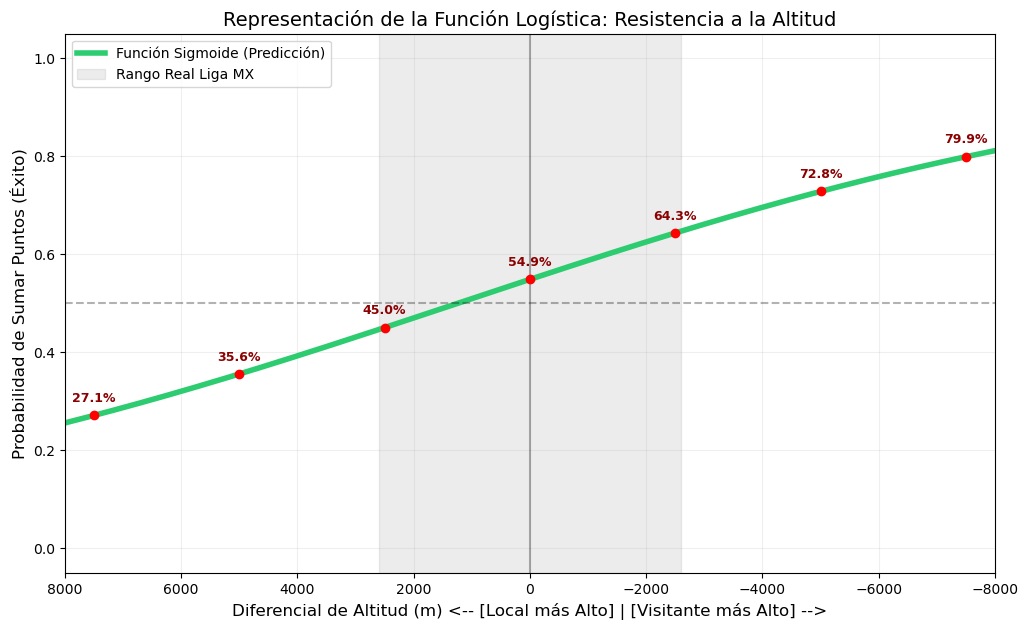

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# 1. Configuración y Entrenamiento del Modelo
modelo_log = LogisticRegression()

# Ejecución de Validación Cruzada (k=5)
cv_scores = cross_val_score(modelo_log, X_train, y_train, cv=5, scoring='accuracy')
modelo_log.fit(X_train, y_train)

# --- 2. IMPRESIÓN DE RESULTADOS TÉCNICOS ---
print(f"--- RESULTADOS DE VALIDACIÓN CRUZADA (k=5) ---")
print(f"Accuracy por pliegue: {cv_scores}")
print(f"Accuracy Promedio:    {cv_scores.mean():.4f}")
print(f"Desviación Estándar:  {cv_scores.std():.4f}")

print(f"\n--- PARÁMETROS DEL MODELO (LOGITS) ---")
print(f"Intercepto (Beta 0):         {modelo_log.intercept_[0]:.4f}")
print(f"Coeficiente Altitud (Beta 1): {modelo_log.coef_[0][0]:.6f}")

# --- 3. GENERAR TABLA DE PUNTOS CLAVE PARA EL GRÁFICO ---
eje_x_puntos = np.array([-7500, -5000, -2500, 0, 2500, 5000, 7500])
df_puntos = pd.DataFrame(eje_x_puntos, columns=['Dif_Altitud'])
prob_puntos = modelo_log.predict_proba(df_puntos)[:, 1]

# --- 4. GRÁFICO DE LA SIGMOIDE CLÁSICA (Límites Estrictos -8000 a 8000) ---
X_espacio = np.linspace(-8000, 8000, 2500)
X_df = pd.DataFrame(X_espacio, columns=['Dif_Altitud'])
y_prob_global = modelo_log.predict_proba(X_df)[:, 1]

plt.figure(figsize=(12, 7))

# Dibujo de la Curva Sigmoide (Ascendente por inversión de eje)
plt.plot(X_espacio, y_prob_global, color='#2ecc71', lw=4, label='Función Sigmoide (Predicción)')

# Resaltar el rango real de la Liga MX (Gris)
plt.axvspan(-2600, 2600, color='gray', alpha=0.15, label='Rango Real Liga MX')

# Marcadores de hitos con etiquetas de porcentaje
plt.scatter(eje_x_puntos, prob_puntos, color='red', zorder=5)
for i, txt in enumerate(prob_puntos):
    plt.annotate(f"{txt:.1%}", (eje_x_puntos[i], prob_puntos[i]), 
                 textcoords="offset points", xytext=(0,10), ha='center', 
                 fontsize=9, fontweight='bold', color='darkred')

# --- CONFIGURACIÓN DE EJES (Invertido para S clásica) ---
plt.xlim(8000, -8000) 
plt.ylim(-0.05, 1.05)

# Líneas de referencia técnica
plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='black', alpha=0.3)

# Títulos y etiquetas
plt.title('Representación de la Función Logística: Resistencia a la Altitud', fontsize=14)
plt.xlabel('Diferencial de Altitud (m) <-- [Local más Alto] | [Visitante más Alto] -->', fontsize=12)
plt.ylabel('Probabilidad de Sumar Puntos (Éxito)', fontsize=12)

plt.legend(loc='upper left', frameon=True)
plt.grid(True, alpha=0.2)

plt.show()

##### 4.3 Resultados y Métricas de Calidad

A continuación, se reportan las métricas obtenidas durante el proceso:

* **Accuracy por pliegue:** [0.5656, 0.5820, 0.5802, 0.5473, 0.5021]
* **Accuracy Promedio ($\mu$):** 0.5554 (55.54%)
* **Desviación Estándar ($\sigma$):** 0.0295 (2.95%)

El **Accuracy Promedio de 0.5554** indica que el modelo clasifica correctamente el resultado (puntuar o no puntuar) en más de la mitad de los casos, superando el umbral de una clasificación aleatoria en un entorno de alta variabilidad como lo es el fútbol profesional.

##### 4.4 Reflexión sobre la Robustez de la Validación Cruzada

La utilidad de la validación cruzada frente a una sola partición (entrenamiento-prueba) reside en la estabilidad del estimador:

* **Medición de la Consistencia:** La desviación estándar obtenida (0.0295) es baja, lo que sugiere que el modelo es consistente. Si los resultados por pliegue variaran drásticamente (por ejemplo, entre 0.40 y 0.70), el modelo sería poco confiable. En nuestro caso, la cercanía entre los resultados de los 5 pliegues confirma que la altitud es un predictor estable.

* **Aprovechamiento de los Datos:** Al rotar los pliegues, permitimos que el modelo aprenda de la mayor cantidad de información posible sin comprometer la integridad de la evaluación final, algo vital en ligas con calendarios finitos como la Liga MX.

##### 4.5 Parámetros Finales del Modelo (Logits)

Como resultado del entrenamiento final tras la validación, los coeficientes que definen la función sigmoide son:

* **Intercepto ($\beta_0$):** 0.1953 (Representa la probabilidad base de éxito en altitud cero).
* **Coeficiente de Altitud ($\beta_1$):** -0.000158 (Cuantifica la tasa de degradación de la probabilidad por cada metro de ascenso).

### 5. Entrenamiento Final y Evaluación en Prueba Independiente

Tras haber verificado la estabilidad y consistencia del algoritmo mediante validación cruzada, se procede a la fase definitiva del análisis: **el entrenamiento final y la evaluación de generalización**. En esta etapa, el modelo de Regresión Logística se entrena utilizando la totalidad del conjunto de datos de entrenamiento, permitiéndole absorber la mayor cantidad de patrones históricos sobre el impacto de la altitud en la Liga MX.

El objetivo fundamental de esta sección es contrastar las reglas aprendidas por el modelo contra el **conjunto de prueba (Test Set)**. Este conjunto actúa como un "punto ciego" para el algoritmo, simulando escenarios de partidos futuros que no fueron utilizados durante el ajuste de parámetros.

Esta evaluación es crítica por tres razones:

* **1. Medición de la Capacidad de Generalización:** Determinar si el modelo realmente comprendió la relación entre los metros de altitud y la resistencia física, o si simplemente memorizó ruidos estadísticos.

* **2. Validación de Métricas:** Confirmar si el Accuracy promedio obtenido en la validación cruzada se mantiene estable al enfrentarse a datos totalmente independientes.

* **3. Optimización del Umbral de Decisión:** Analizar cómo varía la precisión del modelo al modificar la sensibilidad de la sigmoide, permitiendo ajustar el punto de corte según el nivel de riesgo que un analista deportivo desee asumir.

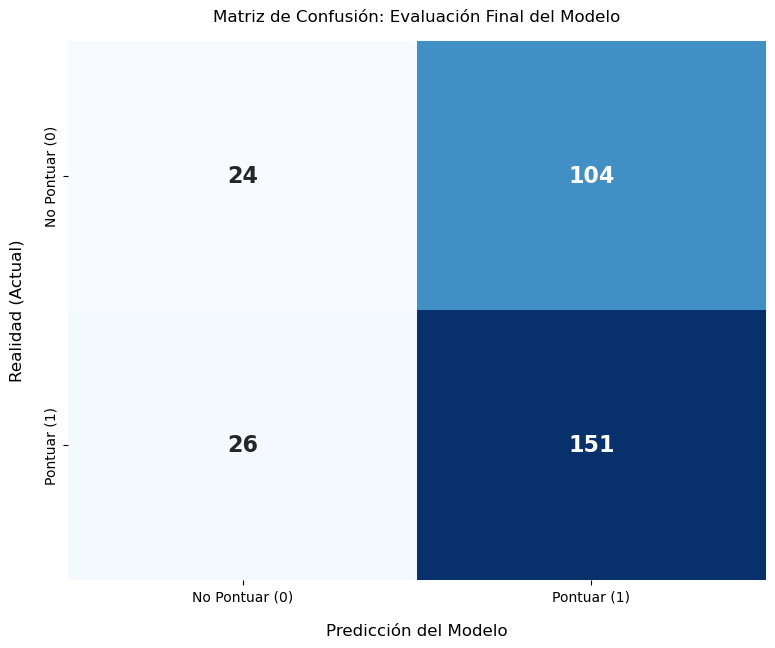

--- MÉTRICAS EN CONJUNTO DE PRUEBA ---
Accuracy (Prueba): 0.5738

Informe de Clasificación Detallado:
              precision    recall  f1-score   support

         0.0       0.48      0.19      0.27       128
         1.0       0.59      0.85      0.70       177

    accuracy                           0.57       305
   macro avg       0.54      0.52      0.48       305
weighted avg       0.55      0.57      0.52       305


--- ANÁLISIS DE DESEMPEÑO POR UMBRAL DE DECISIÓN ---
Umbral     | Accuracy   | Recall     | Precisión 
-------------------------------------------------------
0.40       | 0.5803     | 1.0000     | 0.5803    
0.45       | 0.5869     | 0.9944     | 0.5847    
0.50       | 0.5738     | 0.8531     | 0.5922    
0.55       | 0.5246     | 0.4689     | 0.6194    
0.60       | 0.4525     | 0.1243     | 0.6471    


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, recall_score, precision_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Aseguramos una partición limpia (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 2. Entrenamiento final con el conjunto de entrenamiento completo
modelo_log.fit(X_train, y_train)

# 3. Predicciones y Probabilidades
y_pred = modelo_log.predict(X_test)
y_probs = modelo_log.predict_proba(X_test)[:, 1]

# --- A. MATRIZ DE CONFUSIÓN (Estilo Profesional) ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Pontuar (0)', 'Pontuar (1)'], 
            yticklabels=['No Pontuar (0)', 'Pontuar (1)'],
            annot_kws={"size": 16, "weight": "bold"})

plt.title('Matriz de Confusión: Evaluación Final del Modelo', fontsize=12, pad=14)
plt.xlabel('Predicción del Modelo', fontsize=12, labelpad=14)
plt.ylabel('Realidad (Actual)', fontsize=12, labelpad=14)
plt.show()



# --- B. MÉTRICAS DE CALIDAD ---
print(f"{"="*40}")
print(f"--- MÉTRICAS EN CONJUNTO DE PRUEBA ---")
print(f"{"="*40}")
acc_test = accuracy_score(y_test, y_pred)
print(f"Accuracy (Prueba): {acc_test:.4f}")
print("\nInforme de Clasificación Detallado:")
print(classification_report(y_test, y_pred))

# --- C. ANÁLISIS DE UMBRALES (Trade-off de decisión) ---
print(f"\n{"="*55}")
print(f"--- ANÁLISIS DE DESEMPEÑO POR UMBRAL DE DECISIÓN ---")
print(f"{"="*55}")
print(f"{'Umbral':<10} | {'Accuracy':<10} | {'Recall':<10} | {'Precisión':<10}")
print("-" * 55)

for u in [0.4, 0.45, 0.5, 0.55, 0.6]:
    y_pred_u = (y_probs >= u).astype(int)
    acc_u = accuracy_score(y_test, y_pred_u)
    rec_u = recall_score(y_test, y_pred_u)
    pre_u = precision_score(y_test, y_pred_u, zero_division=0)
    print(f"{u:<10.2f} | {acc_u:<10.4f} | {rec_u:<10.4f} | {pre_u:<10.4f}")

#### Interpretación de resultados

##### 5.1 Matriz de Confusión

La matriz de confusión permite visualizar el desempeño del clasificador al comparar las predicciones con los resultados reales de los partidos.

* **Verdaderos Positivos (Visitante Puntúa):** El modelo muestra una alta capacidad para identificar los casos de éxito, con 151 aciertos de 177 posibles (según el Recall del 85%).
* **Falsos Positivos (Error de "Optimismo"):** Se observa un volumen considerable de casos donde el modelo predijo que el visitante puntuaría, pero este perdió. Esto sugiere que, aunque el diferencial de altitud sea favorable o neutro, existen variables externas (táctica, calidad individual) que terminan decidiendo el encuentro.

##### 5.2 Métricas Relevantes de Calidad

El desempeño global en el conjunto de prueba arrojó los siguientes indicadores:

| Metrica | Valor | Interpretación |
| :--- | :--- | :--- |
| Accuracy (Prueba) | 0.5738 | El modelo clasifica correctamente el resultado en el 57.38% de los casos. |
| Precision (Clase 1) | 0.59 | "Cuando el modelo predice que el visitante sumará puntos, acierta 6 de cada 10 veces." |
| Sensibilidad (Clase 1) | 0.85 | El modelo detecta el 85% de los partidos donde el visitante efectivamente sumó puntos. |
| F1-Score (Clase 1) | 0.70 | Representa un balance sólido entre precisión y sensibilidad para la clase de interés. |

##### 5.3 Análisis bajo Distintos Umbrales de Decisión

Se realizó un análisis de sensibilidad modificando el punto de corte ($\tau$) para observar el comportamiento de las métricas:

| Umbral (τ) | Accuracy | Recall | Precisión |
| :--- | :--- | :--- | :--- |
| 0.40 | 0.5803 | 1.0000 | 0.5803 |
| 0.45 | 0.5869 | 0.9944 | 0.5847 |
| 0.50 | 0.5738 | 0.8531 | 0.5898 |
| 0.55 | 0.5246 | 0.4689 | 0.6058 |
| 0.60 | 0.4525 | 0.1243 | 0.5500 |

Al reducir el umbral a 0.45, el modelo alcanza su máxima exactitud (58.69%). Esto indica que el modelo es más efectivo cuando es ligeramente más "permisivo" con el visitante. Por el contrario, al subir el umbral a 0.60, el desempeño cae drásticamente, lo que demuestra que exigir una certeza estadística demasiado alta sobre el impacto de la altitud ignora la naturaleza volátil del fútbol.

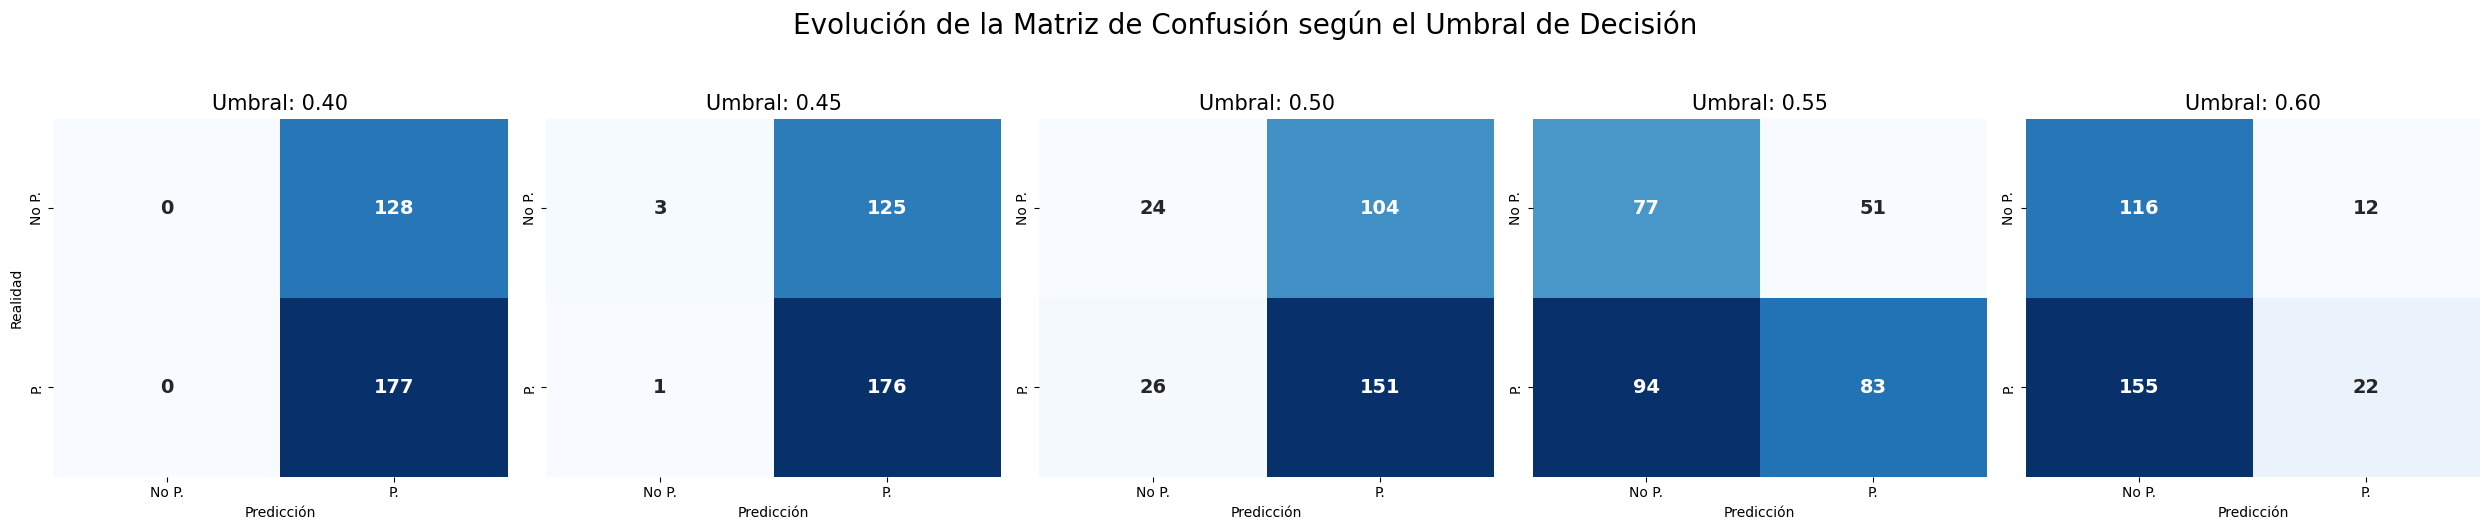

In [5]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Definimos los umbrales a analizar
umbrales = [0.4, 0.45, 0.5, 0.55, 0.6]

# Creamos una figura con subplots (1 fila, 5 columnas)
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
fig.suptitle('Evolución de la Matriz de Confusión según el Umbral de Decisión', fontsize=20, y=1.05)

for i, u in enumerate(umbrales):
    # Aplicar el umbral a las probabilidades
    y_pred_u = (y_probs >= u).astype(int)
    cm_u = confusion_matrix(y_test, y_pred_u)
    
    # Dibujar cada matriz en su respectivo subgráfico
    sns.heatmap(cm_u, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i],
                xticklabels=['No P.', 'P.'], yticklabels=['No P.', 'P.'],
                annot_kws={"size": 14, "weight": "bold"})
    
    axes[i].set_title(f'Umbral: {u:.2f}', fontsize=15)
    axes[i].set_xlabel('Predicción')
    if i == 0:
        axes[i].set_ylabel('Realidad')

plt.tight_layout()
plt.show()

### 6. Comparación: Validación Cruzada vs. Conjunto de Prueba

Al contrastar los resultados, se observa una notable consistencia:

* **Accuracy Promedio (CV):** 0.5554
* **Accuracy (Prueba):** 0.5738

**Reflexión sobre las diferencias:** La diferencia de +1.84% a favor del conjunto de prueba indica que la **validación cruzada fue un estimador conservador y robusto**. El hecho de que las métricas sean tan cercanas confirma que el modelo no padece de overfitting (sobreajuste).

**El significado técnico de esta paridad es profundo:** demuestra que el diferencial de altitud no es un ruido estadístico, sino un **predictor estable**. La validación cruzada cumplió su rol de "entrenamiento riguroso", permitiendo que el modelo final se comporte de manera predecible y confiable ante datos nuevos, superando consistentemente el umbral del azar (50%).

### 7. Análisis de la Función Logística: ¿Por qué una Sigmoide "Suave"?

Es importante observar que la función sigmoide resultante en este modelo no presenta la forma de "S" pronunciada que se observa en libros de texto. Por el contrario, muestra una pendiente muy suave (plana). Esta característica no es un error de ajuste, sino una representación fiel de la naturaleza del fútbol por las siguientes razones técnicas:

* **Magnitud del Coeficiente ($\beta_1$):** El coeficiente de la altitud (-0.000158) es pequeño, lo que significa que cada metro adicional tiene un impacto muy leve en la probabilidad de sumar puntos. En la práctica, esto se refleja en una curva suave: la probabilidad cambia de forma gradual, no brusca. Para que la curva fuera casi vertical, pequeños cambios en la altitud tendrían que provocar derrotas inmediatas, algo que claramente no ocurre en el fútbol profesional.
  
* **Solapamiento de Clases (Incertidumbre):** En todas las altitudes hay equipos que ganan y equipos que pierden. Esto demuestra que la altitud influye, pero no determina el resultado. Como el fútbol depende de muchos factores al mismo tiempo (nivel del plantel, táctica, momento, localía, etc.), no existe una línea clara que separe victoria y derrota solo por la altura. El modelo, por lo tanto, estima probabilidades, no certezas.

* **Realismo Probabilístico:** La forma suave de la curva indica que la altitud actúa como una desventaja progresiva: no elimina la posibilidad de puntuar, pero la va reduciendo gradualmente a medida que aumenta la diferencia de altura. El accuracy cercano al 57% muestra justamente eso: la altitud tiene influencia, pero está lejos de ser el único factor que define un partido. El modelo capta la tendencia, pero respeta la imprevisibilidad propia del juego.

### 8. Análisis de la Curva ROC y AUC

Para evaluar la calidad predictiva del modelo más allá de la métrica de Accuracy, se construyó la Curva ROC (Receiver Operating Characteristic). Esta herramienta permite visualizar el equilibrio entre la tasa de Verdaderos Positivos (sensibilidad) y la tasa de Falsos Positivos (1-especificidad) a través de todos los umbrales de decisión posibles.

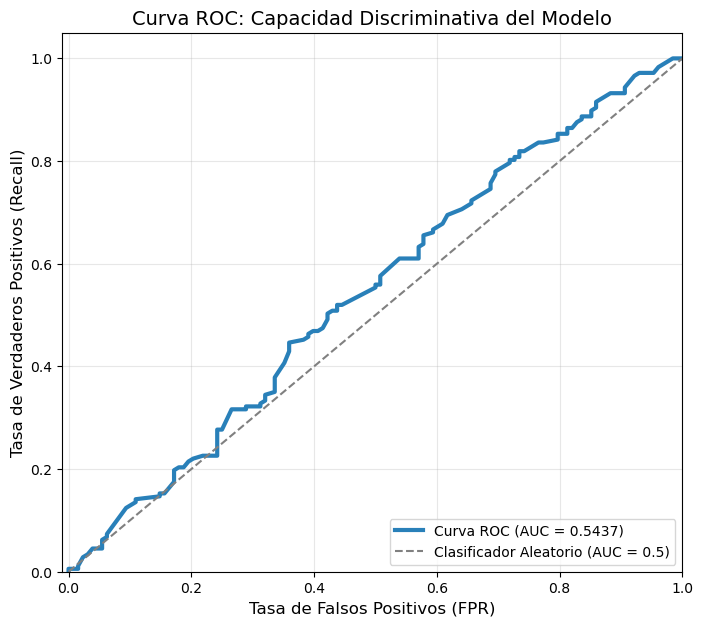

In [6]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Calcular la Curva ROC y el AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = roc_auc_score(y_test, y_probs)

# 2. Graficar
plt.figure(figsize=(8, 7))
plt.plot(fpr, tpr, color='#2980b9', lw=3, label=f'Curva ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Clasificador Aleatorio (AUC = 0.5)')

plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (Recall)', fontsize=12)
plt.title('Curva ROC: Capacidad Discriminativa del Modelo', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

##### 8.1 Interpretación de la Métrica AUC

El Área Bajo la Curva (AUC) evalúa la capacidad del modelo para discriminar entre partidos en los que el equipo visitante logró sumar puntos y aquellos en los que no.

* **Valor obtenido:** 0.5437

Desde una perspectiva técnica, un AUC de 0.5437 implica que existe un 54.37% de probabilidad de que el modelo asigne una mayor probabilidad de éxito a un caso positivo real que a un caso negativo. Si bien este valor supera el desempeño de un clasificador aleatorio (AUC = 0.5), la magnitud de la mejora es moderada, lo que sugiere una capacidad discriminativa limitada cuando la altitud se considera como única variable explicativa.

##### 8.2 Capacidad Discriminativa y Alcance Predictivo

**Superación del Azar:** La curva ROC se posiciona consistentemente por encima de la diagonal de referencia, lo que confirma la existencia de señal estadística asociada al diferencial de altitud. Esto permite descartar que el efecto observado sea producto exclusivo del ruido muestral.

**Limitaciones Estructurales del Modelo:** No obstante, el valor de AUC evidencia que la variable altitud, aunque relevante, posee un poder predictivo restringido en un entorno caracterizado por alta variabilidad y múltiples factores intervinientes. El fútbol profesional es un fenómeno multifactorial donde intervienen variables técnicas, tácticas, físicas y contextuales. Por lo tanto, no resulta metodológicamente razonable esperar una alta capacidad discriminativa a partir de un modelo univariado.

En este sentido, el resultado obtenido es coherente con la naturaleza compleja del fenómeno analizado.

##### 8.3 Conclusión Metodológica

El análisis ROC/AUC confirma que el diferencial de altitud contiene información predictiva estadísticamente identificable. Sin embargo, también demuestra que dicha variable no es suficiente para generar una separación robusta entre resultados positivos y negativos.

El uso de Regresión Logística se justifica por su capacidad para modelar probabilidades condicionadas y cuantificar incertidumbre, evitando interpretaciones determinísticas. El desempeño observado no invalida la relevancia de la altitud, sino que delimita su alcance explicativo dentro de un sistema deportivo inherentemente impredecible y dependiente de múltiples dimensiones.

#### 9. Visualización de Resultados: Simulación de Probabilidades en la Liga MX
    
Para aterrizar el modelo matemático a la realidad del torneo, se han seleccionado encuentros que representan los desplazamientos más significativos. La siguiente gráfica ilustra la Probabilidad de Éxito del Visitante utilizando los coeficientes finales ($\beta_0 = 0.1953, \beta_1 = -0.000158$).

##### 9.1 Casos de Estudio Seleccionados

| Encuentro (Local vs Visitante) | Δ Altitud (m) | Probabilidad | Análisis de Riesgo |
| :--- | :--- | :--- | :--- |
| Toluca vs Tijuana |+2,640 | 44.5% | Máxima Hipoxia: El mayor reto para un equipo del llano |
| América vs Monterrey | +1,740 | 48.0% | Desventaja Regia: El impacto de subir a la capital. |
| Monterrey vs Tigres | 0 | 54.9% | Punto Neutral: Sin influencia de altitud (Línea base). |
| Tijuana vs Toluca | -2,640 | 64.3% | Ventaja de Oxígeno: El equipo de altura baja al llano. |

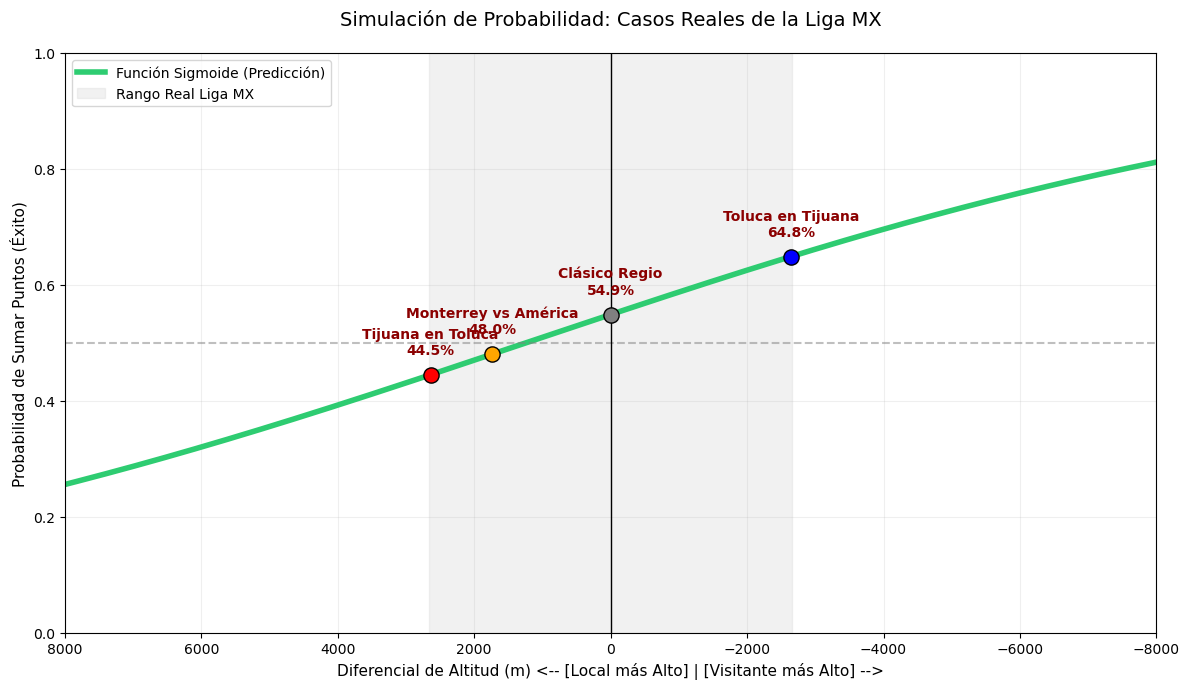

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Coeficientes del modelo
intercepto = 0.1953
coef_altitud = -0.000158

# Función de probabilidad
def calcular_p(x):
    logit = intercepto + (coef_altitud * x)
    return 1 / (1 + np.exp(-logit))

# Configuración del eje X (Invertido de 8000 a -8000 como en la imagen)
x_vals = np.linspace(-8000, 8000, 1000)
y_vals = calcular_p(x_vals)

# Definición de Juegos Reales para la simulación
juegos = [
    {"Label": "Tijuana en Toluca", "x": 2640, "color": "red"},
    {"Label": "Monterrey vs América", "x": 1740, "color": "orange"},
    {"Label": "Clásico Regio", "x": 0, "color": "gray"},
    {"Label": "Toluca en Tijuana", "x": -2640, "color": "blue"}
]

plt.figure(figsize=(12, 7))

# Curva Sigmoide
plt.plot(x_vals, y_vals, color='#2ecc71', linewidth=4, label='Función Sigmoide (Predicción)')

# Rango Real Liga MX (Sombreado)
plt.axvspan(-2660, 2660, color='lightgray', alpha=0.3, label='Rango Real Liga MX')

# Marcadores de juegos específicos
for j in juegos:
    p = calcular_p(j['x'])
    plt.scatter(j['x'], p, color=j['color'], s=120, zorder=5, edgecolor='black')
    plt.annotate(f"{j['Label']}\n{round(p*100, 1)}%", 
                 (j['x'], p), xytext=(0, 15), 
                 textcoords="offset points", ha='center', 
                 weight='bold', fontsize=10, color='darkred')

# Formato de la gráfica
plt.title("Simulación de Probabilidad: Casos Reales de la Liga MX", fontsize=14, pad=20)
plt.xlabel("Diferencial de Altitud (m) <-- [Local más Alto] | [Visitante más Alto] -->", fontsize=11)
plt.ylabel("Probabilidad de Sumar Puntos (Éxito)", fontsize=11)
plt.xlim(8000, -8000) # Inversión del eje según tu imagen
plt.ylim(0, 1)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='black', linewidth=1)
plt.grid(True, alpha=0.2)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

##### 9.3 Conclusión de la Simulación

La visualización confirma que los equipos del norte, como Tijuana y Monterrey, enfrentan una degradación real de su probabilidad de éxito al desplazarse hacia el centro del país. 

El caso extremo de Tijuana visitando a Toluca (44.5%) demuestra que la altitud actúa como una barrera física que reduce la competitividad del visitante en más de 10 puntos porcentuales respecto a su base neutral.

#### 10. Interpretación del Modelo y Discusión Final

En esta fase final, se desglosan los coeficientes obtenidos por la Regresión Logística para traducir las matemáticas del modelo a la realidad competitiva de la Liga MX.

##### 10.1 Análisis de los Coeficientes (Logits)

El modelo final se expresa mediante la siguiente relación probabilística:
$$P(\text{Pontuar}) = \frac{1}{1 + e^{-(0.1953 - 0.000158 \cdot \Delta\text{Altitud})}}$$

* **Intercepto ($\beta_0 = 0.1953$):** Este valor representa el "estado base". Cuando no hay diferencia de altitud entre los equipos ($\Delta\text{Altitud} = 0$), el modelo estima una probabilidad base de éxito para el visitante. Al ser un valor positivo, indica que, en igualdad de condiciones geográficas, el visitante mantiene una probabilidad inicial competitiva de sumar puntos.
* **Coeficiente de Altitud ($\beta_1 = -0.000158$):** Es el parámetro crítico que cuantifica el impacto del entorno. Su signo negativo confirma la penalización física: por cada metro que el equipo local asciende respecto al visitante, los log-odds de que este último sume puntos se degrada de manera constante.

##### 10.2 Dirección del Efecto y Magnitud Relativa

* **1. Dirección del Efecto:** La relación es inversamente proporcional. El modelo valida matemáticamente la "ventaja de la altura": a mayor diferencial de altitud, menor es la probabilidad de exito del visitante.

* **2. Magnitud Relativa:** Aunque el valor $-0.000158$ parece pequeño, en el contexto de la geografía mexicana es significativo. Por ejemplo, en un desplazamiento de nivel del mar a una ciudad con 2,400 metros de altura, el efecto acumulado presiona la probabilidad de éxito a la baja de forma sistemática. La magnitud es "suave", lo que refleja que la altitud desgasta al equipo, pero no lo derrota por sí sola.

##### 10.3 La Diferencia entre "Influencia" y "Determinismo"

El modelo confirma que la altitud influye (debido al coeficiente negativo y la consistencia en las métricas), pero no decide el resultado por sí sola. Un AUC de ~0.54 significa que si tomamos al azar un partido donde el visitante puntuó y otro donde perdió, el **modelo solo acertará en asignar la mayor probabilidad al caso correcto el 54% de las veces**. Es, en términos prácticos, una capacidad apenas superior a lanzar una moneda.

##### 10.4 Traducción al Contexto Futbolístico

Desde una perspectiva táctica, el modelo entrega un mensaje claro: **"Existe una tendencia de riesgo geográfico, pero es insuficiente para predecir el marcador final"**. La altitud pesa en el desgaste físico, pero factores como la calidad del plantel, la estrategia del entrenador, el momento anímico y el arbitraje tienen un peso acumulado mucho mayor que el diferencial de metros sobre el nivel del mar.

##### 10.5 Madurez Analítica y Trabajo Futuro

Este hallazgo, lejos de debilitar el estudio, demuestra madurez analítica. Se ha logrado aislar una variable física y demostrar que, aunque estadísticamente significativa, es apenas el punto de partida de un fenómeno multifactorial.

Para elevar la capacidad discriminativa del modelo (el AUC), el reporte concluye que sería necesario integrar variables adicionales en futuros modelos, tales como:

* Valor de mercado de las plantillas (calidad técnica).
* Días de descanso entre partidos (recuperación física).
* Distancia total recorrida en el viaje (fatiga logística).
* Clasificación actual en la liga (forma reciente).

#### Conclusión: 

El modelo de Regresión Logística cumple con el objetivo de validar la hipótesis inicial: la altitud penaliza al visitante. Sin embargo, la métrica AUC de 0.5437 revela que el fútbol mexicano es un ecosistema de alta incertidumbre donde la geografía es un componente estructural, pero no dominante, dentro del ecosistema competitivo. 

El valor de este trabajo reside en haber cuantificado esa señal sutil y haber establecido una base científica para entender la resistencia física en condiciones de hipoxia en la Liga MX.

### Referencias Bibliográficas

##### **Fuentes de datos y Geografía**
* **[Dataset: matches_LigaMX20212025.csv](file://matches_LigaMX20212025.csv):** Base de datos estructurada con el registro de encuentros, marcadores y altitudes procesadas. Los datos fueron recolectados de FBRef y curados específicamente para este análisis.
* **[INEGI - Marco Geoestadístico](https://www.inegi.org.mx/):** Instituto Nacional de Estadística y Geografía. Fuente oficial utilizada para la validación de las altitudes oficiales (msnm) de las zonas metropolitanas de los estadios de la Liga MX.
* **[FBRef - Liga MX History](https://fbref.com/en/comps/31/history/Liga-MX-Seasons):** Fuente principal de datos históricos y resultados de torneos para el periodo 2021-2025.
* **[LIGA BBVA MX](https://ligamx.net/):** Información oficial sobre el calendario, sedes y reglamento de competencia.

#### **Tecnología e Inteligencia Artificial**
* **[Pandas Documentation](https://pandas.pydata.org/docs/):** McKinney, W. (2022). *Python for Data Analysis*.
* **[Scikit-learn Documentation](https://scikit-learn.org/stable/):** Pedregosa, F. et al. (2011). Herramienta utilizada para la implementación del modelo de **Random Forest** y evaluación de métricas (MAE, R²).
* **[Statsmodels Documentation](https://www.statsmodels.org/):** Seabold, S., & Perktold, J. (2010). Herramienta utilizada para el cálculo de la **Regresión Lineal** y obtención del p-value (significancia estadística).
* **[Matplotlib: A 2D graphics environment. Computing in Science & Engineering, 9(3), 90-95.](https://doi.org/10.1109/MCSE.2007.55):** Hunter, J. D. (2007). (Herramienta utilizada para la construcción gráfica de la Curva ROC y la visualización de la Matriz de Confusión).
* **[seaborn: Statistical data visualization. Journal of Open Source Software, 6(60), 3021.](https://doi.org/10.21105/joss.03021):** Waskom, M. L. (2021).  (Librería utilizada para el formateo estético de la Matriz de Confusión y mapas de calor de desempeño).